In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

In [ ]:
csv_files = sorted(glob.glob("data/loan_approval_*.csv"))

df = pd.concat([pd.read_csv(f, sep="|") for f in csv_files], ignore_index=True)
df = df.dropna(subset=["Applicant_Income", "CoApplicant_Income", "Loan_Amount", "Married", "Loan_Status"])

print(f"{len(csv_files)} Dateien eingelesen -> {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

df.head()

5 Dateien eingelesen -> 4838 Zeilen, 14 Spalten


,Num_Kids,Loan_ID,Gender,Married,Dependent_No,Education,Self_Employed,Applicant_Income,CoApplicant_Income,Loan_Amount,Loan_Amount_Term,Credit History,Property_District,Loan_Status
0,-,27471,Male,True,1,Not Graduate,True,4251,34868.0,30000,300,1,CCR,1
1,-,27472,Male,False,1,Graduate,False,23399,30710.0,30000,60,1,OCR,1
2,-,27473,Female,False,4,Not Graduate,True,68684,13669.0,50000,180,1,OCR,1
3,-,27474,Male,False,3,Graduate,True,19825,20862.0,10000,360,0,OCR,1
4,-,27475,Male,True,3,Not Graduate,True,65643,15199.0,60000,240,0,OCR,1


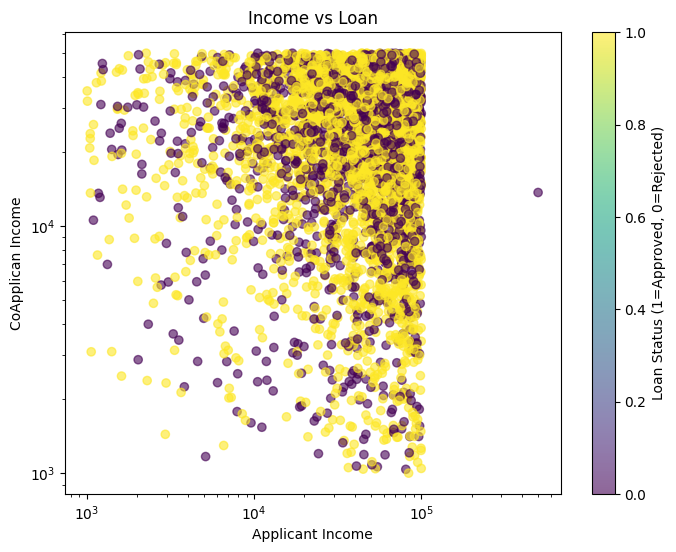

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["Applicant_Income"],
    df["CoApplicant_Income"],
    c=df["Loan_Status"],
    alpha=0.6
)

plt.xlabel("Applicant Income")
plt.ylabel("CoApplican Income")
plt.title("Income vs Loan")

# logarithmische skalierung (sieht gleich aus) (optional)
plt.xscale("log")
plt.yscale("log")

plt.colorbar(label="Loan Status (1=Approved, 0=Rejected)")
plt.show()

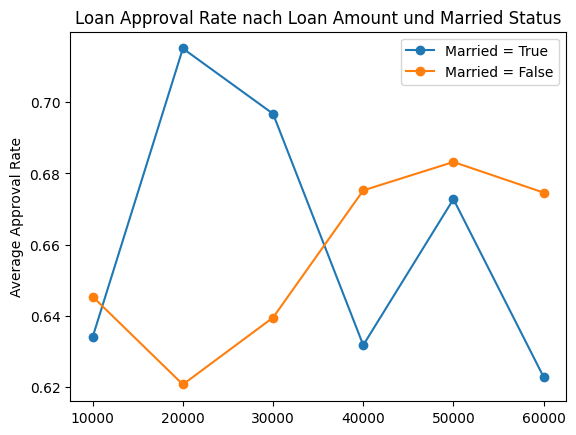

In [ ]:
df = df.dropna(subset=["Loan_Amount", "Married", "Loan_Status"])
df = df.drop_duplicates()

df["Married_Num"] = df["Married"].map({True: 1, False: 0})


married_groups = df.groupby(["Loan_Amount", "Married_Num"])["Loan_Status"].mean().unstack()

plt.plot(married_groups.index.astype(str), married_groups[1], marker='o', label="Married = True")
plt.plot(married_groups.index.astype(str), married_groups[0], marker='o', label="Married = False")

plt.ylabel("Average Approval Rate")
plt.title("Loan Approval Rate nach Loan Amount und Married Status")
plt.legend()
plt.show()